# Tirando sinais digitais - $x[n]$ ... pra fora do computador - $x(t)$!

Neste Notebook iremos trabalhar em como:
1. Criar um sinal `osc`, com frequência e duração controladas.
2. Sintetizar um sinal ***periódico e aleatório***, com frequência e duração controladas.
3. Plotar sinais em amostras, $x[n]$, tempo, $x(t)$, e frequência, $\mathcal{X}(\omega)$.

In [136]:
import numpy as np
import matplotlib.pyplot as plt

In [137]:
import sys

In [138]:
try:
    from google.colab import drive

    drive.mount('/content/drive')
    sys.path.append('/content/drive/MyDrive/UFG/01_teaching/')

except:
    # sys.path.append('/home/kuntur/Documents') # laptop version
    sys.path.append('/media/sdcard/Documents/') # tablet version
    sys.path.append('../../') # repositorio local (lib/)

In [139]:
from lib.myAudioProcessingLib import *
from lib.mySignalProcessingLib import *
# from lib.myPlotLib import *

Complete a função `create_sine_signal`, que permite criar um **sinal oscilatório** (*le03, p. 24*):

$$
\Large
x[n] = \, A \sin\left(\frac{2\pi}{P} n + \phi\right)
$$

controlado pela sua:

- ***frequência*** $(f)$ [Hz] (*le04, p. 11*):

$$
\Large
f = \, \frac{f_{s}}{P} \quad \Rightarrow \quad P = \frac{f_{s}}{f}
$$

- e ***duração*** $(d)$ [s] :

$$
\Large
d = N \, T_{s}
$$

In [140]:
def create_sine_signal(f=440.0, dur=1.0, fs=48e3):
    '''
    f  : Signal frequency (Hz)
    dur: Duration (s)
    fs : Sampling frequency
    '''

    N = int(dur * fs)  # d = N Ts  =>  N = d fs
    P = fs / f         # f = fs / P  =>  P = fs / f
    n = np.arange(N)

    x = np.sin(2 * np.pi / P * n)

    return x, fs

teste sua função, para um sinal de 220 Hz e 1.5 segundos de duração:

In [91]:
f   = 220.0
dur = 1.5

x1, fs1 = create_sine_signal(f, dur)

In [147]:
play(x1, fs1)

Qual é a ***frequencia audível*** do sinal?

In [148]:
# Resposta
# A frequência audível é a própria frequência do oscilador: f = 220 Hz (nota Lá 3).
print(f'Frequência audível: {f} Hz')

Frequência audível: 110.0 Hz


Qual é o período $(P_{1})$, tamanho $(N_{1})$, e frequência de amostragem $(f_{s_{1}})$ do sinal?

In [149]:
P1 = fs1 / f
N1 = len(x1)

print(P1, N1, fs1)

436.3636363636364 72000 48000.0


Se mudar a frequencia de amostragem, o que acontece?

In [150]:
# Resposta
# Como a função recalcula P = fs/f e N = d*fs, mudar fs mantém a frequência (220 Hz) e a
# duração (1.5 s): muda apenas quantas amostras há por período (P) e no total (N).
x1b, fs1b = create_sine_signal(f, dur, fs=24e3)
print(fs1b / f, len(x1b), fs1b)

# Já se o MESMO x[n] for reproduzido com outra fs, o som muda: com 2*fs o tom
# sobe uma oitava (440 Hz) e dura metade do tempo (0.75 s).
play(x1, 2 * fs1)

218.1818181818182 24000 24000.0


Agora vamos recriar a mesma função a partir da nossa conhecida primitiva `osc`:

In [151]:
fs2  = 44.1e3

P2 = fs2 / f
N2 = int(dur * fs2)

x2, n2 = SIGNALgenerate(N2, 'osc', period=P2)

In [153]:
play(x2, fs2)

Compare o período $(P_{2})$, tamanho $(N_{2})$, e frequência de amostragem $(f_{s_{2}})$ deste novo sinal com o anterior:

In [154]:
print(P2, N2, fs2)

print(P1, N1, fs1)

400.90909090909093 44100 44100.0
436.3636363636364 72000 48000.0


In [155]:
# Resposta
# Mesma frequência (220 Hz) e mesma duração (N/fs = 1.5 s) nos dois sinais, mas com
# fs2 = 44.1 kHz < fs1 = 48 kHz cada período tem menos amostras (P2 ~ 200.5 < P1 ~ 218.2)
# e o sinal todo também (N2 = 66150 < N1 = 72000).
print(N1 / fs1, N2 / fs2)

1.5 1.0


Para verificar o resultado, plote os dois sinais resultantes no "***domínio do tempo***", ou seja, mostrando o **eixo horizontal** em unidade de **segundos**:

$$
\Large
t = n \, T_{s}
$$

***Dica:*** Use `SIGNALplot` para plotar o sinal. \
Se precisar, faça um recorte para melhorar a visualização dos sinais.

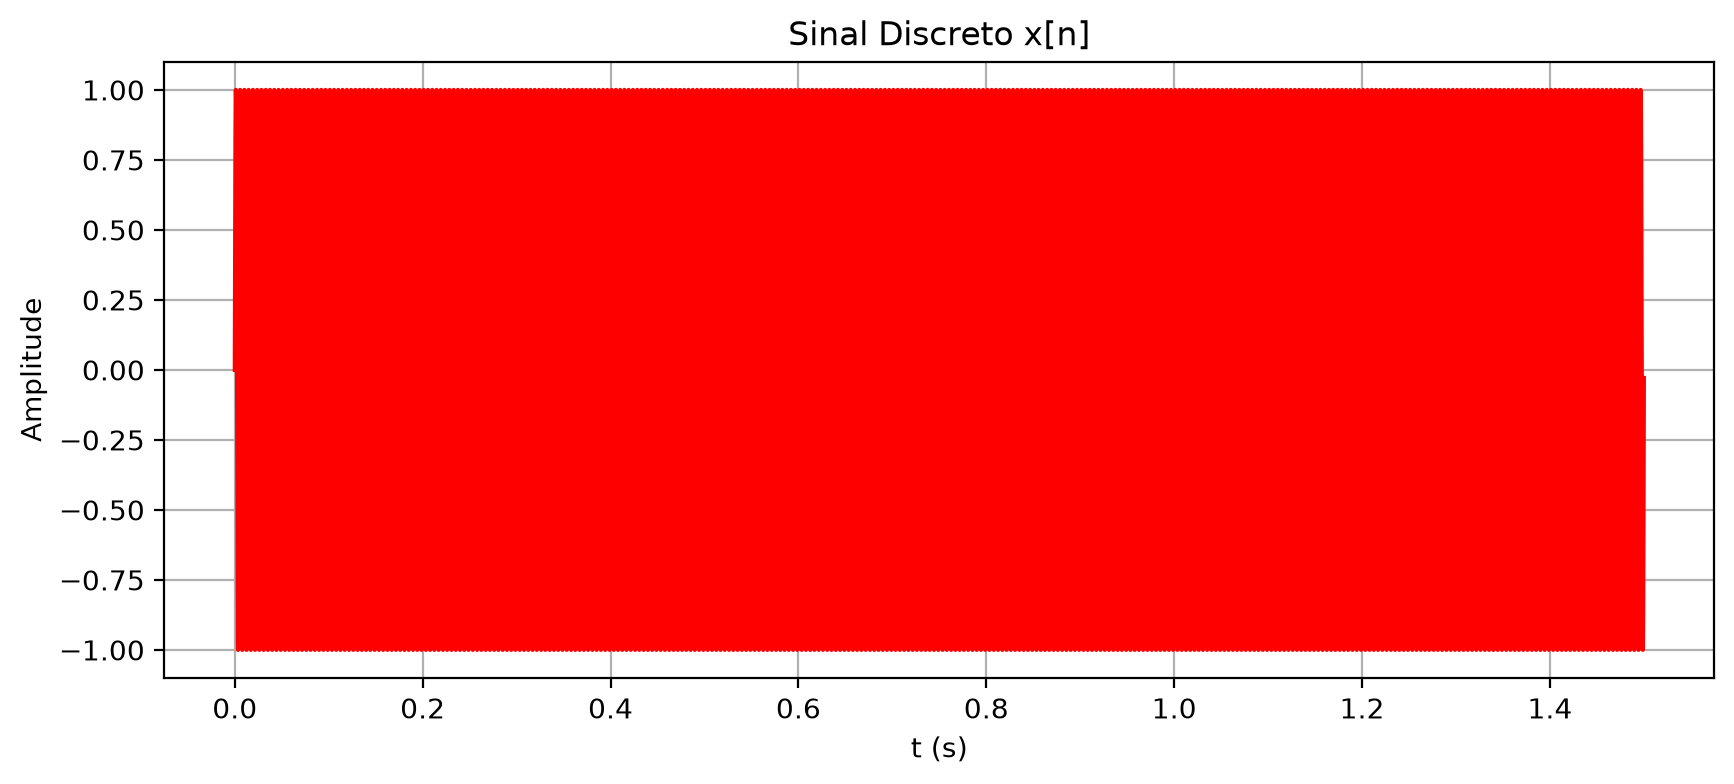

In [100]:
'''
Vetor de tempo
'''
n1 = np.arange(N1)
t1 = n1 / fs1

'''
Plot
'''
SIGNALplot(x1, t1, xlabel='t (s)')

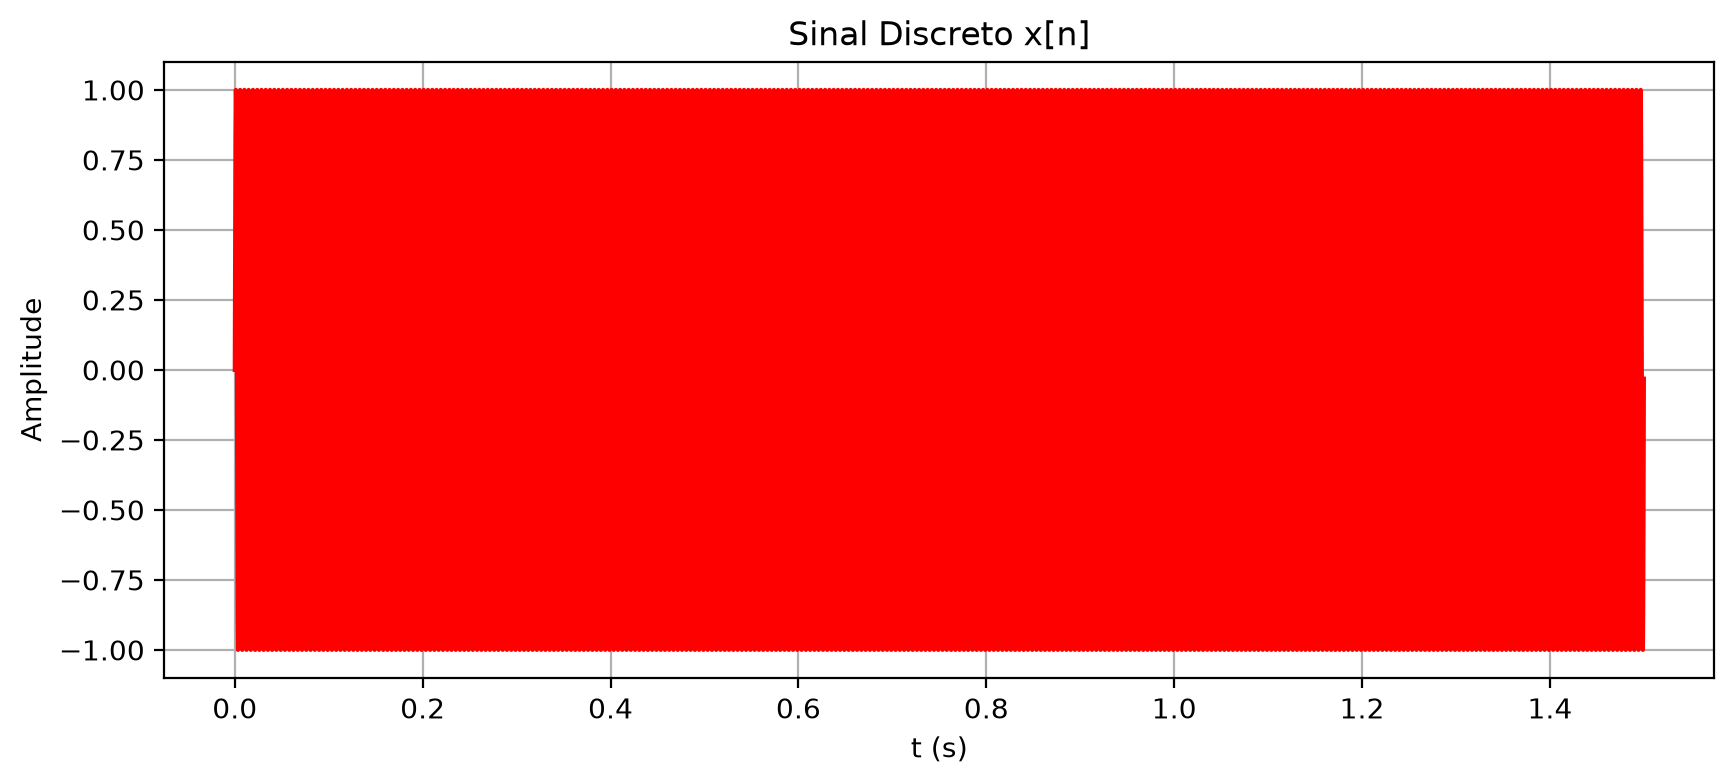

In [101]:
'''
Vetor de tempo
'''
t2 = n2 / fs2

'''
Plot
'''
SIGNALplot(x2, t2, xlabel='t (s)')

<img src="./figures/sine_01.png" alt="" width="600"/>

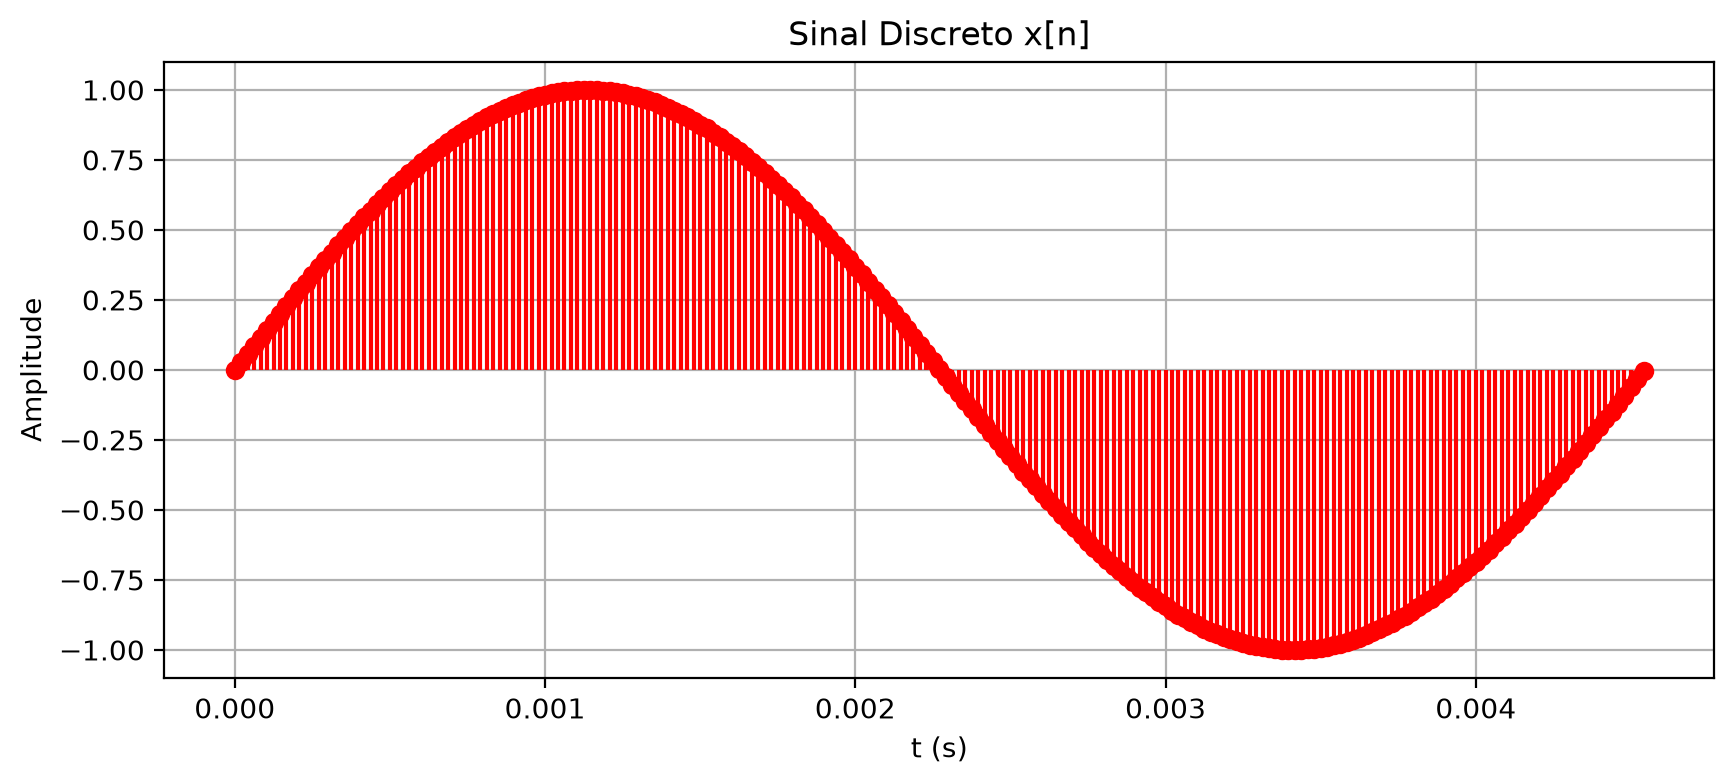

In [102]:
'''
Recorte
'''
r = int(np.ceil(P1)) # ~1 período

'''
Plot
'''
SIGNALplot(x1[:r], t1[:r], xlabel='t (s)')

<img src="./figures/sine_02.png" alt="" width="600"/>

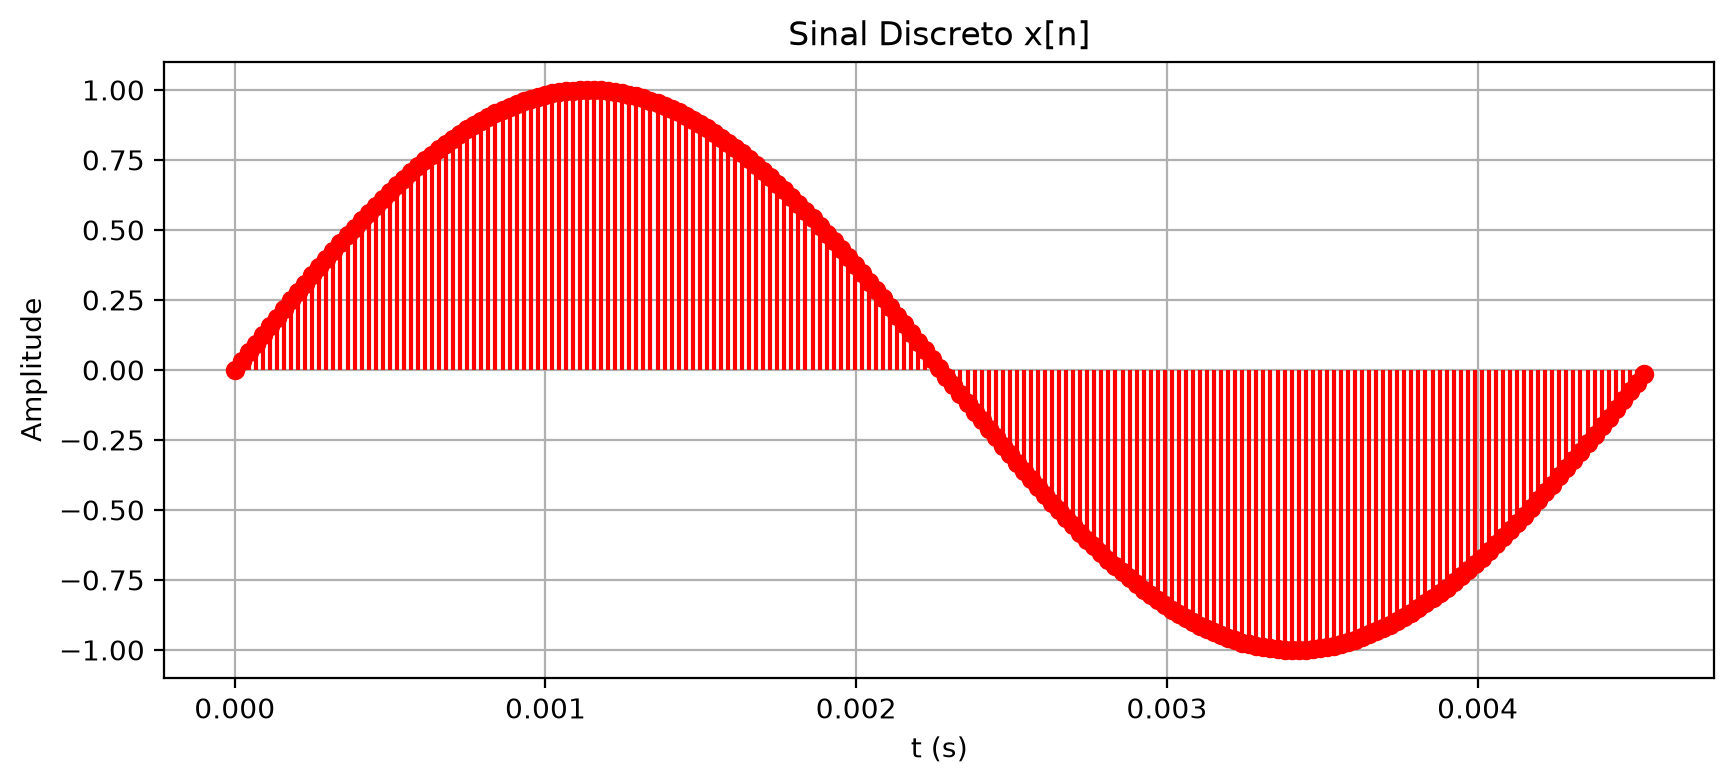

In [103]:
'''
Recorte
'''
r = int(np.ceil(P2)) # ~1 período

'''
Plot
'''
SIGNALplot(x2[:r], t2[:r], xlabel='t (s)')

Faça um novo recorte para plotar ***apenas*** 2.5 períodos de cada sinal.

***Dica:*** Verifique o resultado mostrando o **eixo horizontal** no "***domínio das amostras***".

<img src="./figures/sine_03.png" alt="" width="600"/>

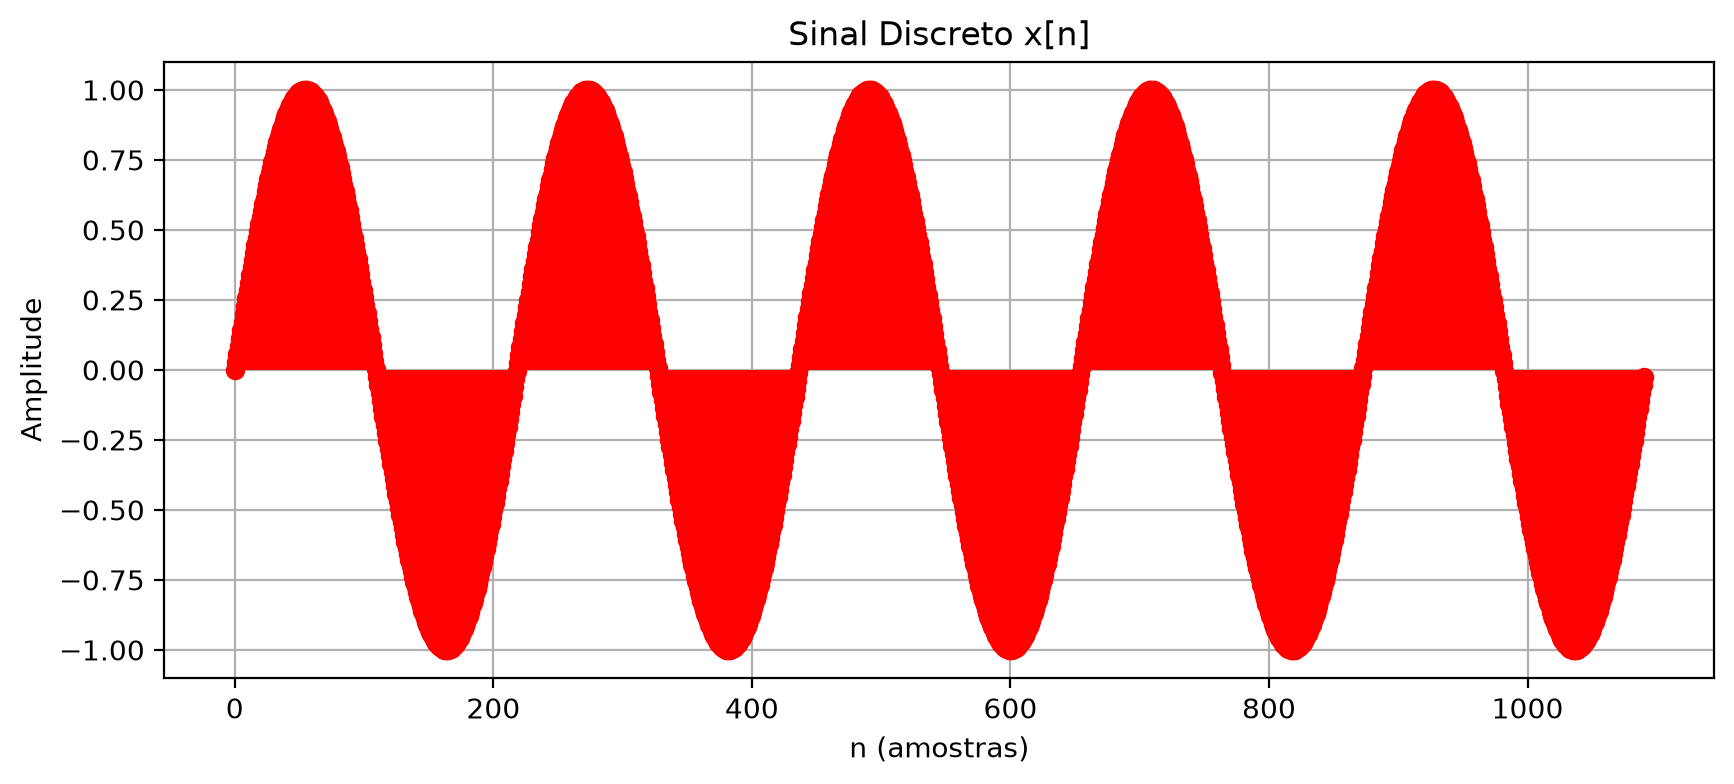

In [156]:
'''
Recorte
'''
r = int(np.round(2.5 * P1))

SIGNALplot(x1[:r], n1[:r])

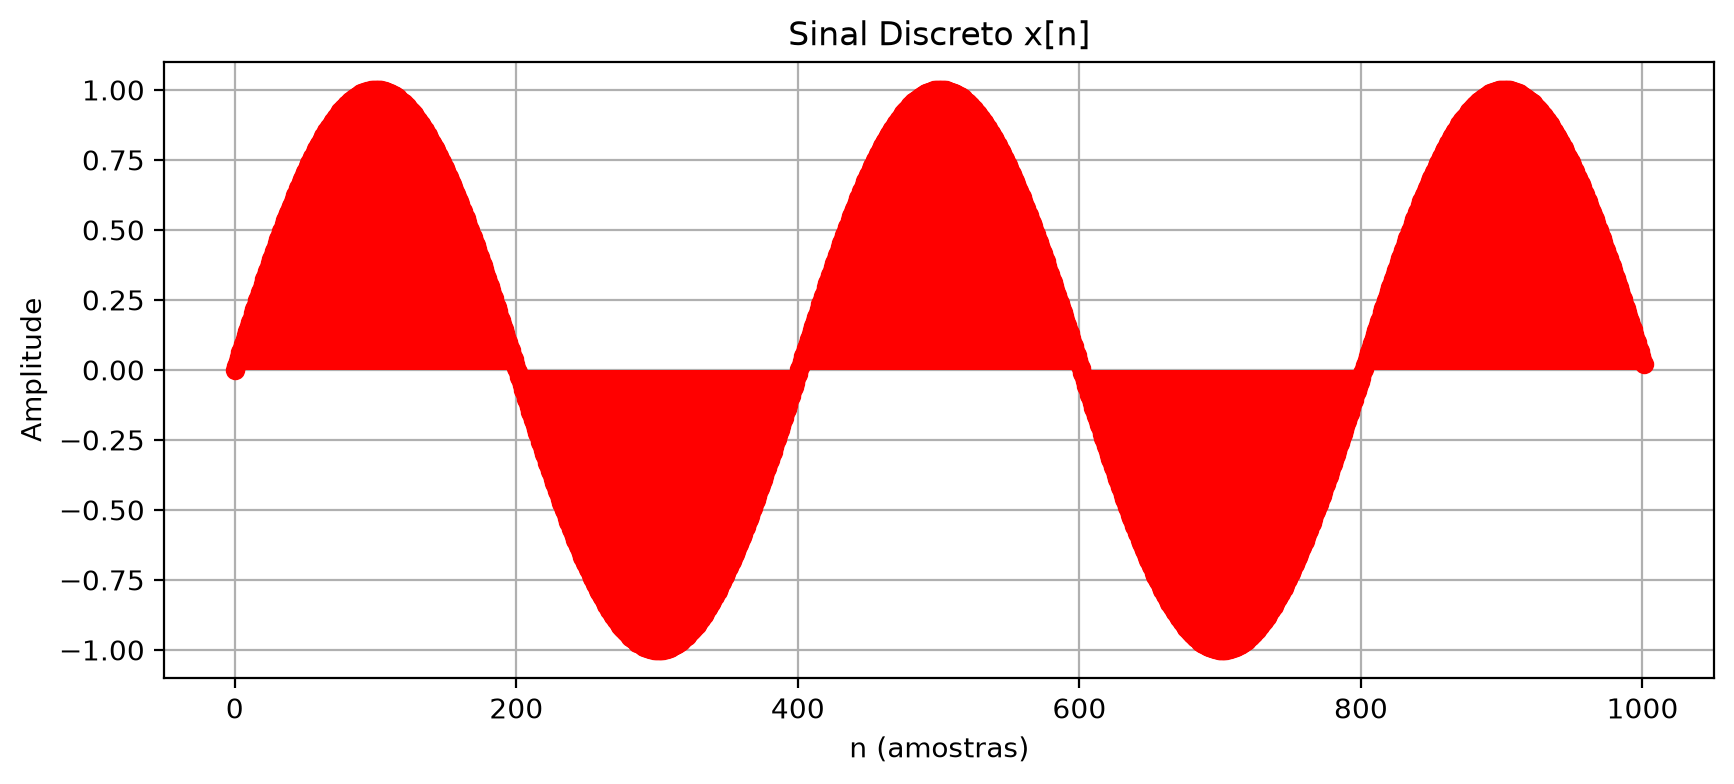

In [160]:
'''
Recorte
'''
#r = int(np.round(2.5 * P2))
r = np.round(2.5 * P2).astype(int)

SIGNALplot(x2[:r], n2[:r])

## Desafio

A partir da primitiva `SIGNALgenerate`, aumente a sua **biblioteca de processamento sinais** com a função `SIGNALtone`, que permita criar um ***tom*** controlado por ***frequencia*** e ***duração***.

In [158]:
def SIGNALtone(f=440.0, dur=1.0):
    '''
    Tone with predefined frequency and duration

    f  : Signal frequency (Hz)
    dur: Duration (s)

    x  : Output signal
    fs : Sampling freq. (CD standard by def.)
    '''

    fs = 44.1e3 # Sampling freq. (CD standard)

    x, _ = SIGNALgenerate(int(dur * fs), 'osc', period=fs / f)

    return x, fs

Teste a função para um sinal de 330 Hz com 3 segundos de duração.

In [162]:
f = 220.0 # signal freq (Hz)
dur = 3.0 # duration (s)

In [163]:
x, fs = SIGNALtone(f, dur)

In [165]:
play(x, fs)

## Revelando a "*velocidade*" dos sinais

Como comprovar que estamos gerando as frequências corretas?

***Dica:*** Estude a função `np.fft.fft` que permite evidenciar as "*velocidades*" de sinais. \
Use `SIGNALplot` para plotar a **magnitude** da FFT no domínio das amostras.

<img src="./figures/spec_01.png" alt="" width="600"/>

In [166]:
# help(np.fft.fft)

In [167]:
# Resposta
X = np.fft.fft(x)

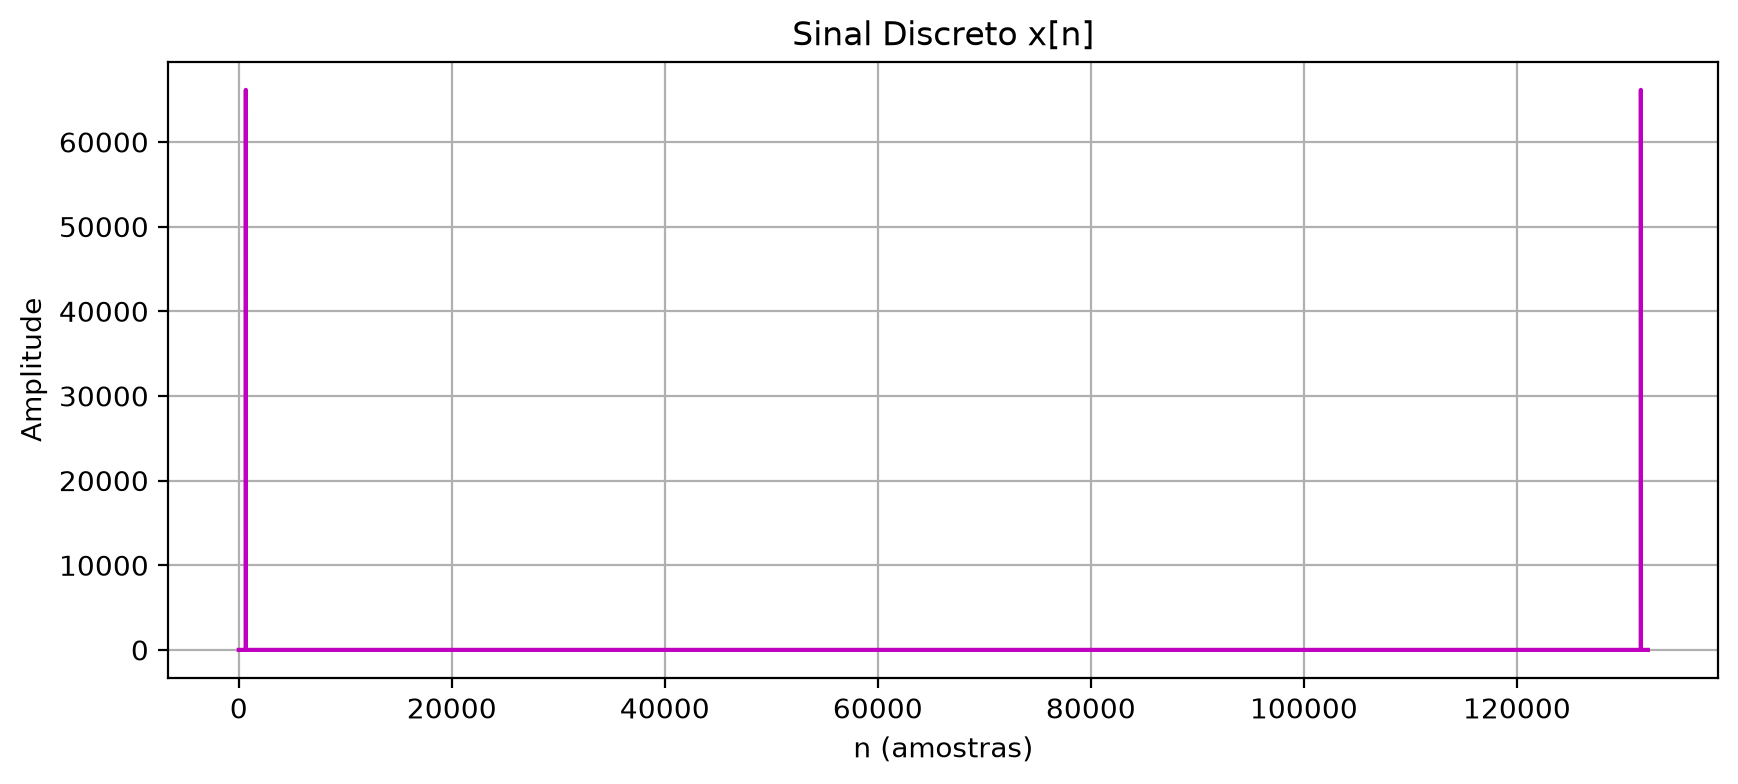

In [168]:
Xmag = np.abs(X)
n = np.arange(len(X))

SIGNALplot(Xmag, n, color='m')

Aproveitando a ***simetria***, faça um recorte, apropriado, de apenas a metade das amostras.

<img src="./figures/spec_02.png" alt="" width="600"/>

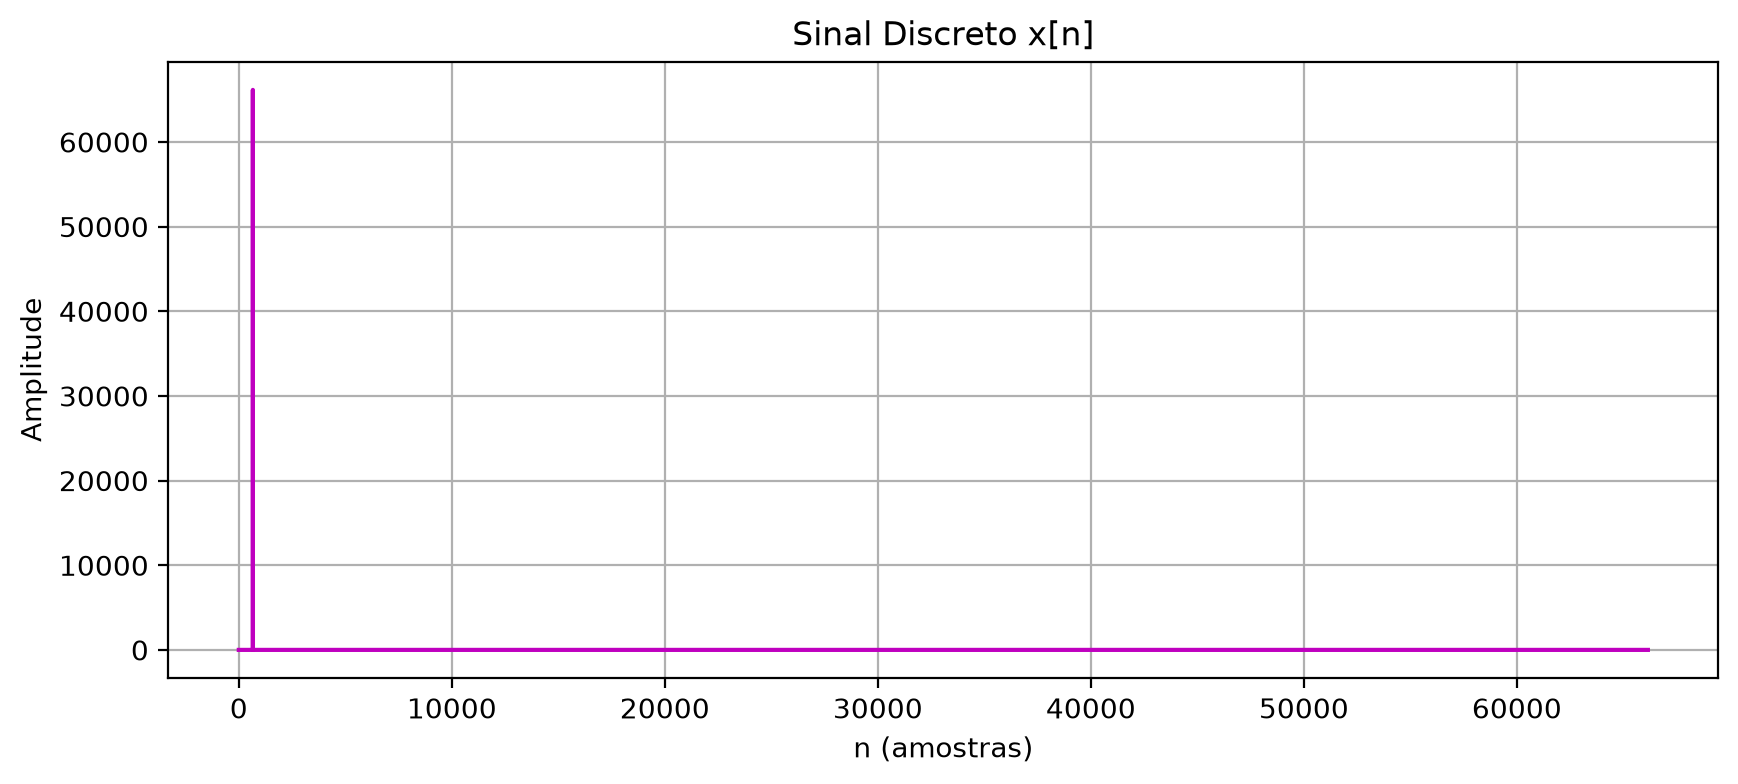

In [169]:
'''
Recorte no dominio das amostras
'''
r = len(Xmag) // 2 # espectro simétrico: basta a metade

SIGNALplot(Xmag[:r], n[:r], color='m')

## Plotando as frequências

Agora vamos renomear o eixo horizontal para apresentar o sinal no "***domínio da frequência***":

$$
\Large
f = \frac{n}{N} f_{s}
$$

<img src="./figures/spec_03.png" alt="" width="600"/>

In [170]:
fHz = n / len(n) * fs

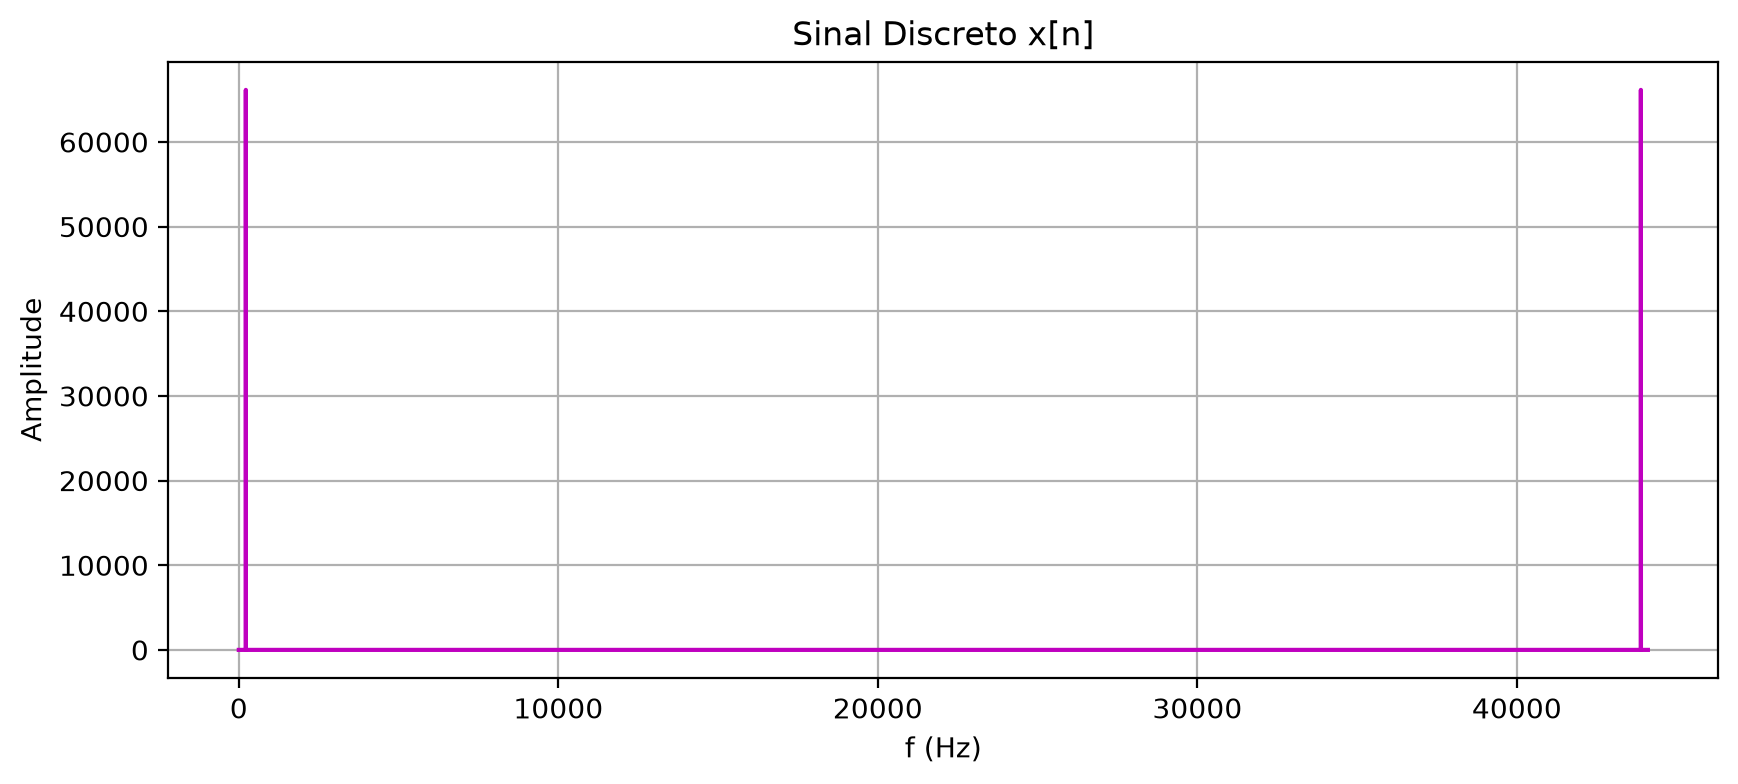

In [171]:
SIGNALplot(Xmag, fHz, color='m', xlabel='f (Hz)')

Aproveite o recorte anterior **no domínio das amostras** e aplique-o no sinal.

<img src="./figures/spec_04.png" alt="" width="600"/>

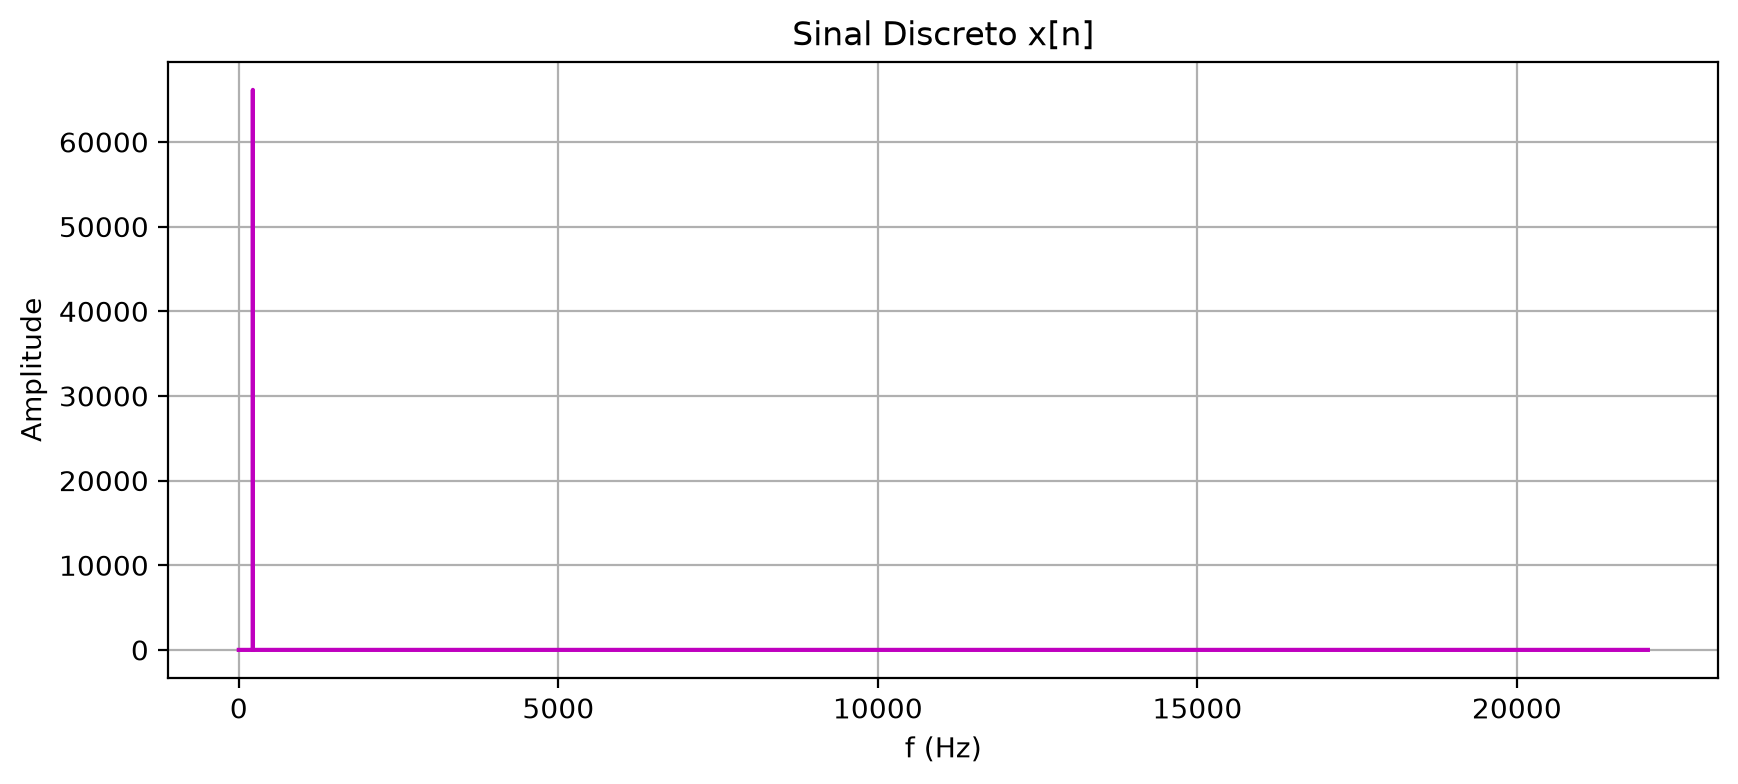

In [172]:
'''
Recorte no dominio das amostras
'''
r = len(Xmag) // 2

SIGNALplot(Xmag[:r], fHz[:r], color='m', xlabel='f (Hz)')

Agora, aplique um recorte similar **no domínio das frequências**.

<img src="./figures/spec_05.png" alt="" width="600"/>

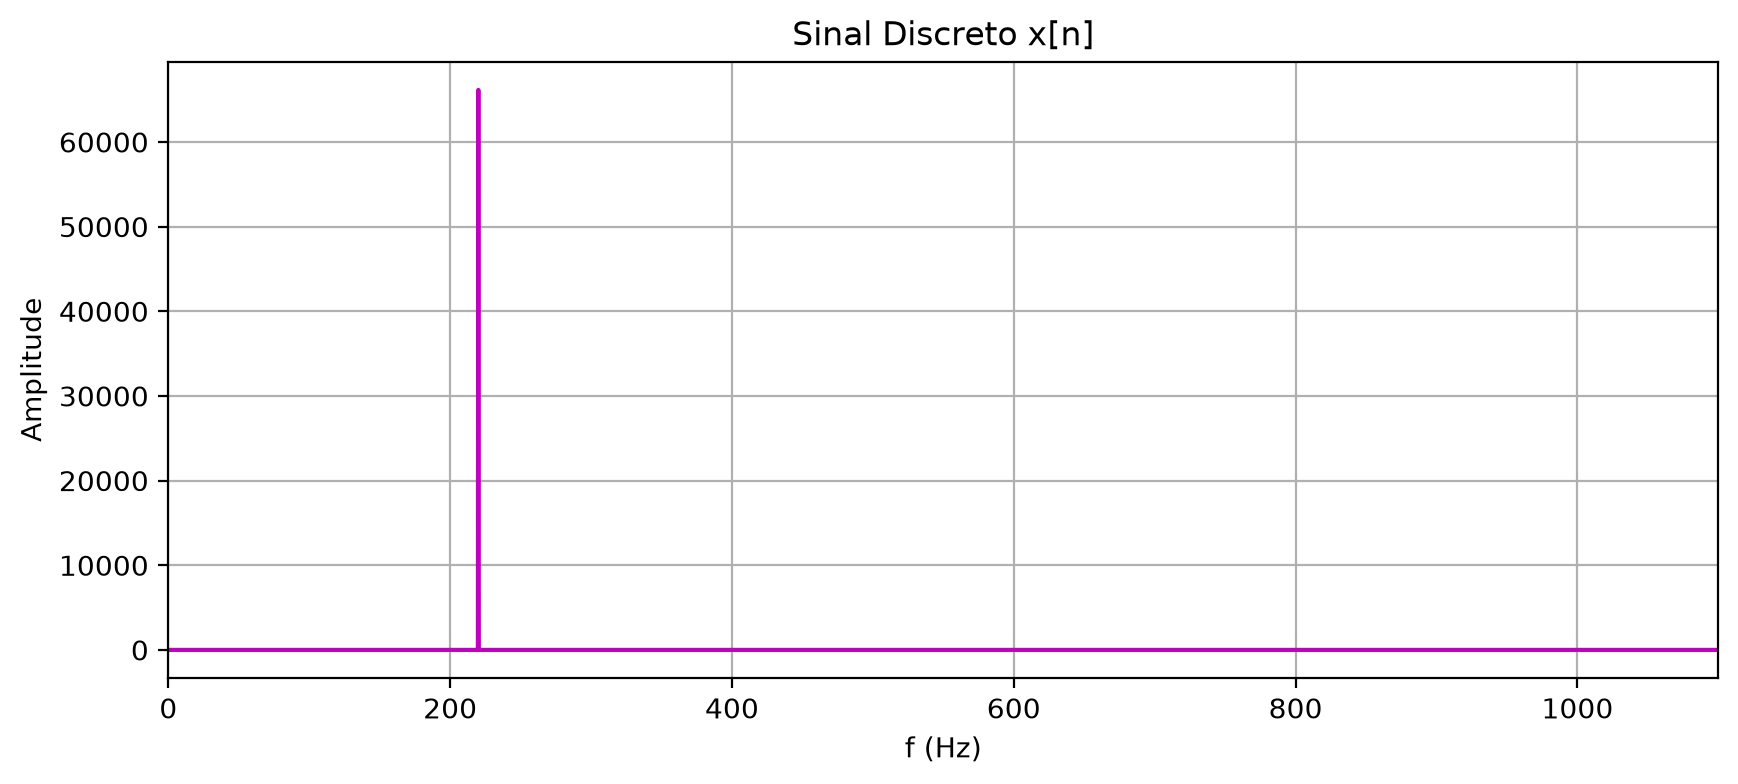

In [173]:
'''
Recorte no dominio das frequencias
'''
SIGNALplot(Xmag, fHz, color='m', xlabel='f (Hz)', \
           xlim=[0, 1100])

Plote a ***forma de onda*** e o ***espectro*** para um único sinal com frequencias de 200, 400, 600 e 800 Hz e 1 segundo de duração.

<img src="./figures/sine_04.png" alt="" width="600"/>

<img src="./figures/spec_06.png" alt="" width="600"/>

In [118]:
# Resposta
fs_x = 44.1e3
dur  = 1.0
N_x  = int(dur * fs_x)

x = np.zeros(N_x)
for fk in [200.0, 400.0, 600.0, 800.0]:
    xk, nx = SIGNALgenerate(N_x, 'osc', period=fs_x / fk, phase=-np.pi / 2) # -cos
    x = x + xk

tx = nx / fs_x

X      = np.fft.fft(x)
Xmag   = np.abs(X)
fHz_x  = nx / N_x * fs_x

In [174]:
play(x, fs_x)

ValueError: could not broadcast input array from shape (132300,) into shape (44100,)

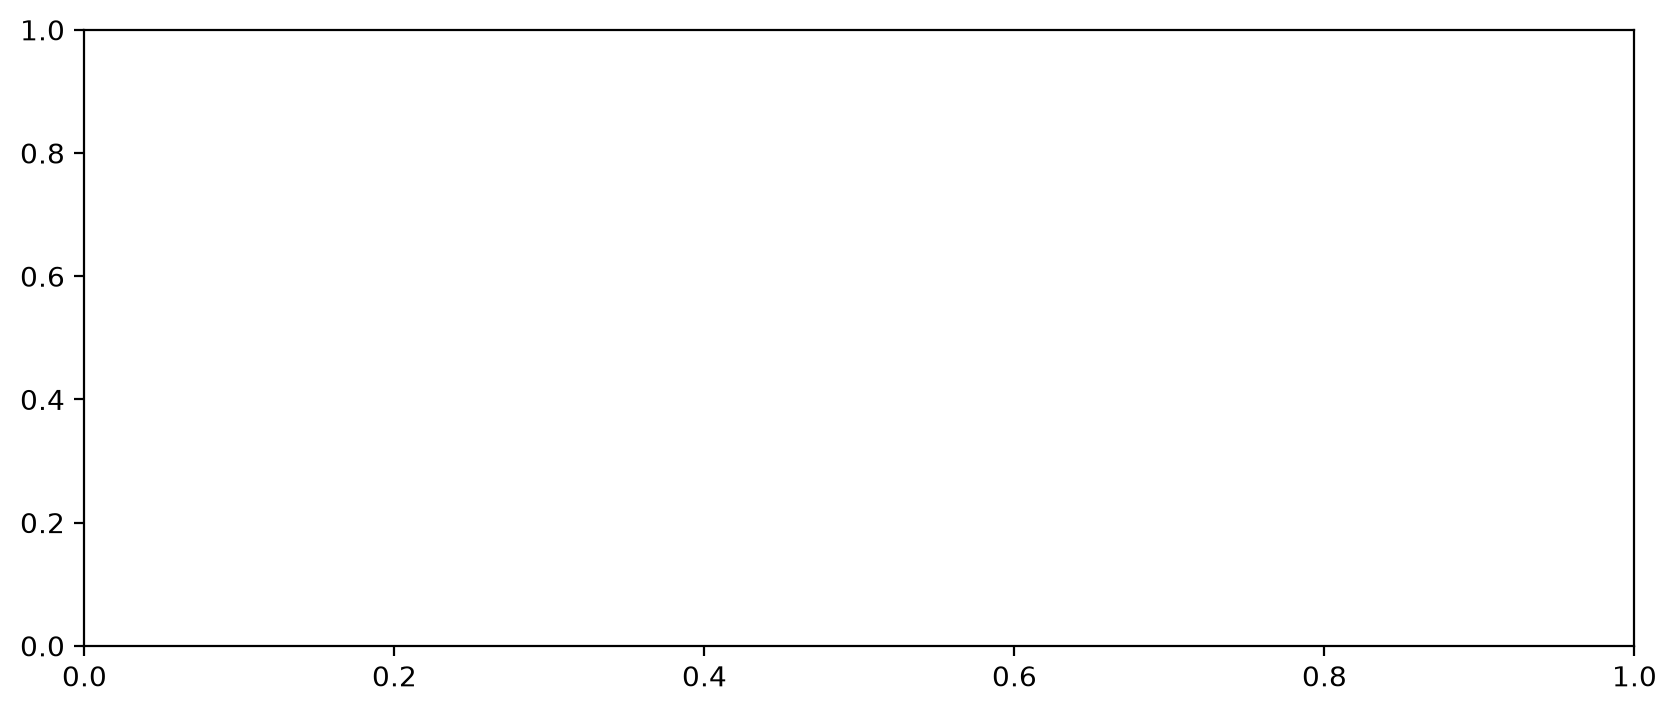

In [175]:
SIGNALplot(x, tx, color='c', xlabel='t (s)', \
          xlim=[0, 0.025])

In [ ]:
SIGNALplot(Xmag, fHz_x, color='m', xlabel='f (Hz)', \
           xlim=[0, 1000])

Oba! Agora sim conseguimos gerar e comprovar as frequencias, ou "*velocidades*", presentes nos sinais!

## Bonus track

A partir da primitiva `SIGNALgenerate`, aumente a sua **biblioteca de processamento sinais** com a função `SIGNALwaveform`, que admita ***tons*** com [***formas de onda*** (*waveforms*)](https://en.wikipedia.org/wiki/Waveform) aleatórias.

***Dica:*** Comece criando um sinal aleatório de tamanho igual a um período. Depois é apenas replicar o sinal até o tamanho final usando `np.concatenate`.

In [176]:
def SIGNALwaveform(f=440.0, dur=1.0):
    '''
    Tone with a random waveform as input

    f  : Signal frequency
    dur: Duration (seconds)

    x  : Output signal
    fs : Sampling freq. (CD standard by def.)
    '''

    fs = 44.1e3 # Sampling freq. (CD standard)

    P = int(np.round(fs / f)) # período em amostras
    N = int(dur * fs)

    waveform, _ = SIGNALgenerate(P, 'random')

    reps = int(np.ceil(N / P))
    x = np.concatenate([waveform] * reps)[:N]

    return x, fs

Teste a função para um sinal de 110 Hz e 1 segundo de duração.

In [184]:
f = 110.0
dur = 1.0

y, fs = SIGNALwaveform(f, dur)

In [185]:
play(y, fs)

Verifique a frequencia do sinal gerado. \
O que achou de diferente nele?

<img src="./figures/spec_07.png" alt="" width="600"/>

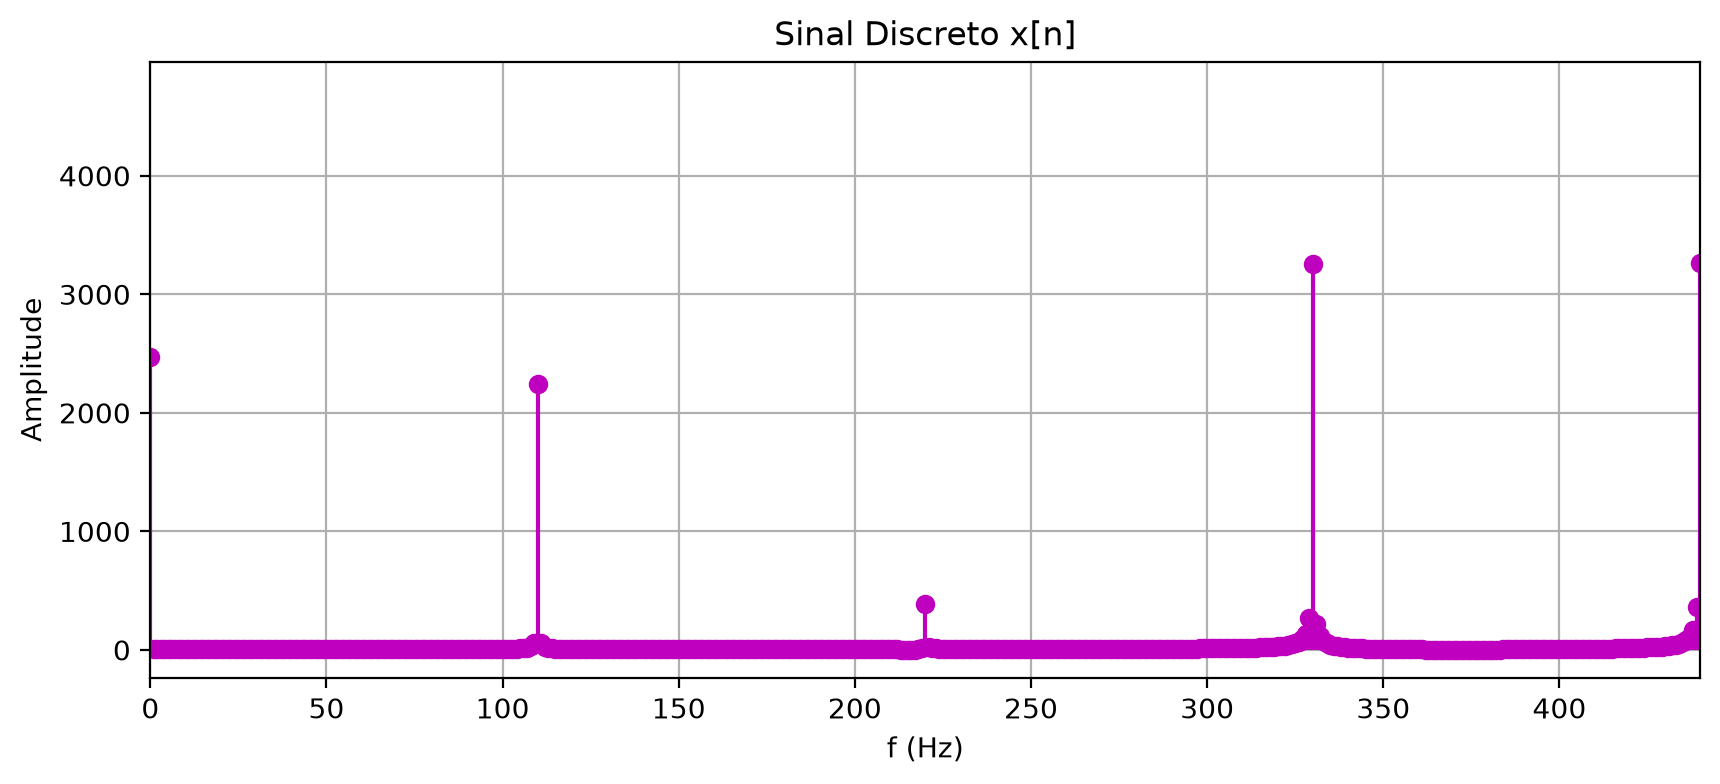

In [179]:
Ymag  = np.abs(np.fft.fft(y))
fHz_y = np.arange(len(y)) / len(y) * fs

SIGNALplot(Ymag, fHz_y, color='m', xlabel='f (Hz)', \
           xlim=[0, 440])

# Diferente do tom senoidal (um único pico), a forma de onda aleatória periódica gera
# picos na fundamental (110 Hz) e em todos os seus harmônicos (220, 330, 440 Hz, ...),
# cada um com amplitude aleatória: é o que dá o "timbre" do sinal.

Plote apenas 5 períodos do sinal.

<img src="./figures/signal_01.png" alt="" width="600"/>

In [180]:
P = int(np.round(fs / f))
ny = np.arange(len(y))

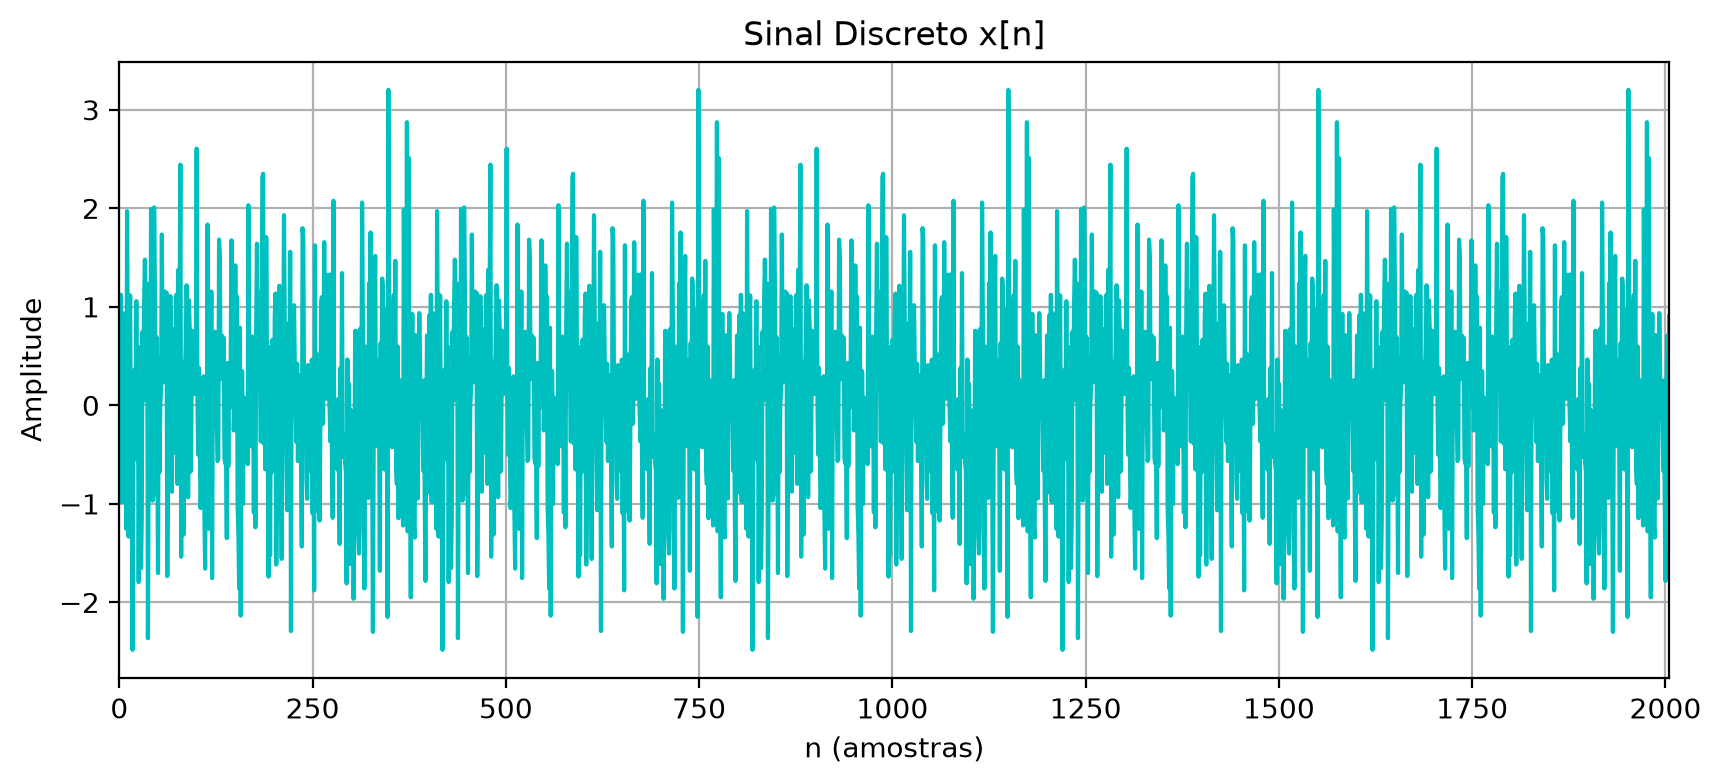

In [181]:
SIGNALplot(y, ny, color='c', \
           xlim=[0, 5 * P])

Pronto! Agora estamos preparados para analisar sinais no ***domínio da frequência!***